# 06 — XAI Analysis: CNN Image Classification (FL vs NFL)

Four complementary explanation methods applied to the CNN models from notebook 05.

| Method | What it answers |
|---|---|
| **GradCAM** | Which spatial region of the image did the model attend to? |

## 1. Setup & Imports

In [2]:
import warnings
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights, EfficientNet_B0_Weights
from PIL import Image

from captum.attr import IntegratedGradients, NoiseTunnel, Occlusion
from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_ROOT     = Path('./breath_images')
FEATURES_CSV = Path('./features_clean.csv')
MODELS_DIR   = Path('./models')
OUT_DIR      = Path('./xai_outputs')
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device : {DEVICE}')

Device : mps


## 2. Rebuild Models & Load Weights

In [3]:
# ── Model definitions (identical to notebook 05) ──────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features   = nn.Sequential(block(3,32), block(32,64), block(64,128), block(128,256))
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(0.4)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)


def build_resnet18():
    m = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.classifier[1].in_features, 2))
    return m


# ── Load saved weights ─────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    'SimpleCNN'      : (SimpleCNN(),          'cnn_simplecnn.pt'),
    'ResNet18'       : (build_resnet18(),      'cnn_resnet18.pt'),
    'EfficientNet-B0': (build_efficientnet_b0(),'cnn_efficientnetb0.pt'),
}

loaded_models = {}
for name, (model, fname) in MODEL_REGISTRY.items():
    path = MODELS_DIR / fname
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval().to(DEVICE)
    loaded_models[name] = model
    print(f'Loaded {name} from {fname}')

# GradCAM target layers (last conv layer for each architecture)
GRADCAM_LAYERS = {
    'SimpleCNN'      : 'features.3.0',   # last Conv2d in block 4
    'ResNet18'       : 'layer4.1.conv2',
    'EfficientNet-B0': 'features.8.0',   # last Conv2d before classifier
}

Loaded SimpleCNN from cnn_simplecnn.pt
Loaded ResNet18 from cnn_resnet18.pt
Loaded EfficientNet-B0 from cnn_efficientnetb0.pt


## 3. Load Image Data & Features

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def participant_from_path(p: Path) -> str:
    return p.stem.rsplit('_breath_', 1)[0]


records = []
for label, target in [('FL', 1), ('NFL', 0)]:
    for p in (IMG_ROOT / label).glob('*.png'):
        records.append({'path': p, 'label': label, 'target': target,
                        'participant': participant_from_path(p),
                        'stem': p.stem})
img_df = pd.DataFrame(records)

# Load feature data — used for TCAV concept labelling
feat_df = pd.read_csv(FEATURES_CSV)

# Build a lookup: stem → feature row
# stem = {participant}_breath_{breath_number}
feat_df = feat_df.dropna(subset=['breath_number']).copy()
feat_df['stem'] = (
    feat_df['participant'].str.replace(' ', '_').str.replace('(','').str.replace(')','') +
    '_breath_' +
    feat_df['breath_number'].astype(int).astype(str)
)
feat_lookup = feat_df.set_index('stem')

# Merge feature values onto image records
CONCEPT_FEATURES = ['quad_insp', 'power_5to12_insp', 'flatness_insp_75']
img_df = img_df.join(
    feat_lookup[CONCEPT_FEATURES],
    on='stem', how='left'
)

matched = img_df[CONCEPT_FEATURES].notna().all(axis=1).sum()
print(f'Total images   : {len(img_df)}')
print(f'Feature-matched: {matched} ({100*matched/len(img_df):.1f}%)')


class BreathDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['target'])


# Sample images for visualisation: 6 FL + 6 NFL
fl_sample  = img_df[img_df['target'] == 1].sample(6, random_state=SEED)
nfl_sample = img_df[img_df['target'] == 0].sample(6, random_state=SEED)
viz_sample = pd.concat([fl_sample, nfl_sample]).reset_index(drop=True)
print(f'Viz sample : {len(viz_sample)} images (6 FL + 6 NFL)')

Total images   : 7007
Feature-matched: 0 (0.0%)
Viz sample : 12 images (6 FL + 6 NFL)


## 4. Helper Utilities

In [5]:
def load_tensor(path: Path, device=DEVICE) -> torch.Tensor:
    """Load a single image as a normalised (1, 3, H, W) tensor."""
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0).to(device)


def tensor_to_display(t: torch.Tensor) -> np.ndarray:
    """Convert a (1,3,H,W) or (3,H,W) normalised tensor back to a displayable (H,W) grayscale array."""
    t = t.squeeze().cpu()
    if t.dim() == 3:
        # Undo normalisation and average channels
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        t = t * std + mean
        t = t.mean(0)
    return t.numpy().clip(0, 1)


def attr_to_heatmap(attr: torch.Tensor) -> np.ndarray:
    """Convert a (1,3,H,W) attribution tensor to a (H,W) signed heatmap."""
    a = attr.squeeze().cpu()
    if a.dim() == 3:
        a = a.sum(0)          # sum across channels
    return a.numpy()


def overlay_heatmap(ax, img_np, heatmap_np, alpha=0.55, symmetric=True):
    """Display image with a transparent heatmap overlay."""
    ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
    if symmetric:
        vmax = max(abs(heatmap_np.min()), abs(heatmap_np.max())) + 1e-8
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        ax.imshow(heatmap_np, cmap='RdBu_r', norm=norm, alpha=alpha)
    else:
        ax.imshow(heatmap_np, cmap='jet',
                  vmin=heatmap_np.min(), vmax=heatmap_np.max(), alpha=alpha)
    ax.axis('off')


print('Utilities defined.')

Utilities defined.


## 5. GradCAM

Registers forward/backward hooks on the last conv layer. The heatmap shows which spatial regions of the waveform image the model used most when making its prediction.

In [6]:
class GradCAM:
    def __init__(self, model: nn.Module, layer_name: str):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._hooks      = []

        # Find target layer by dotted name
        layer = model
        for part in layer_name.split('.'):
            layer = getattr(layer, part)

        self._hooks.append(
            layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o))
        )
        self._hooks.append(
            layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0]))
        )

    def __call__(self, x: torch.Tensor, target_class: int) -> np.ndarray:
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, target_class].backward()

        # Global average pool gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


print('GradCAM defined.')

GradCAM defined.


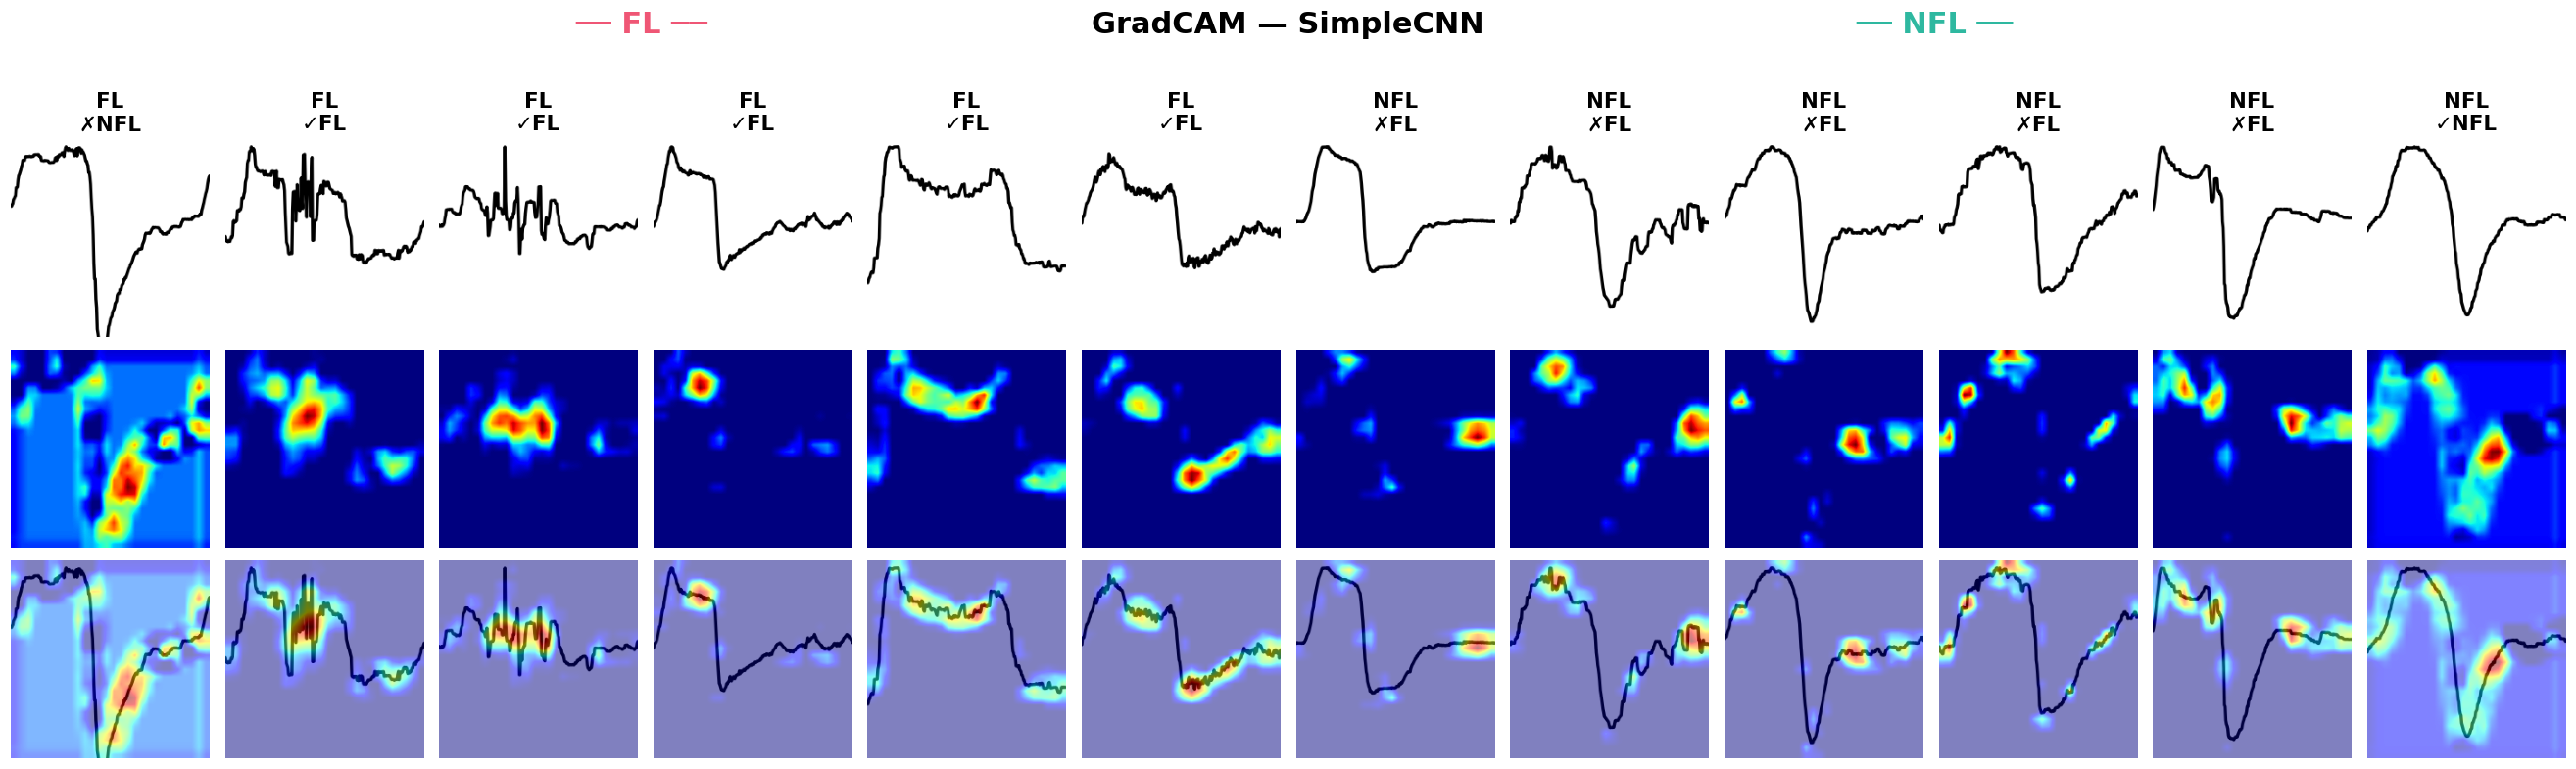

Saved: gradcam_simplecnn.png


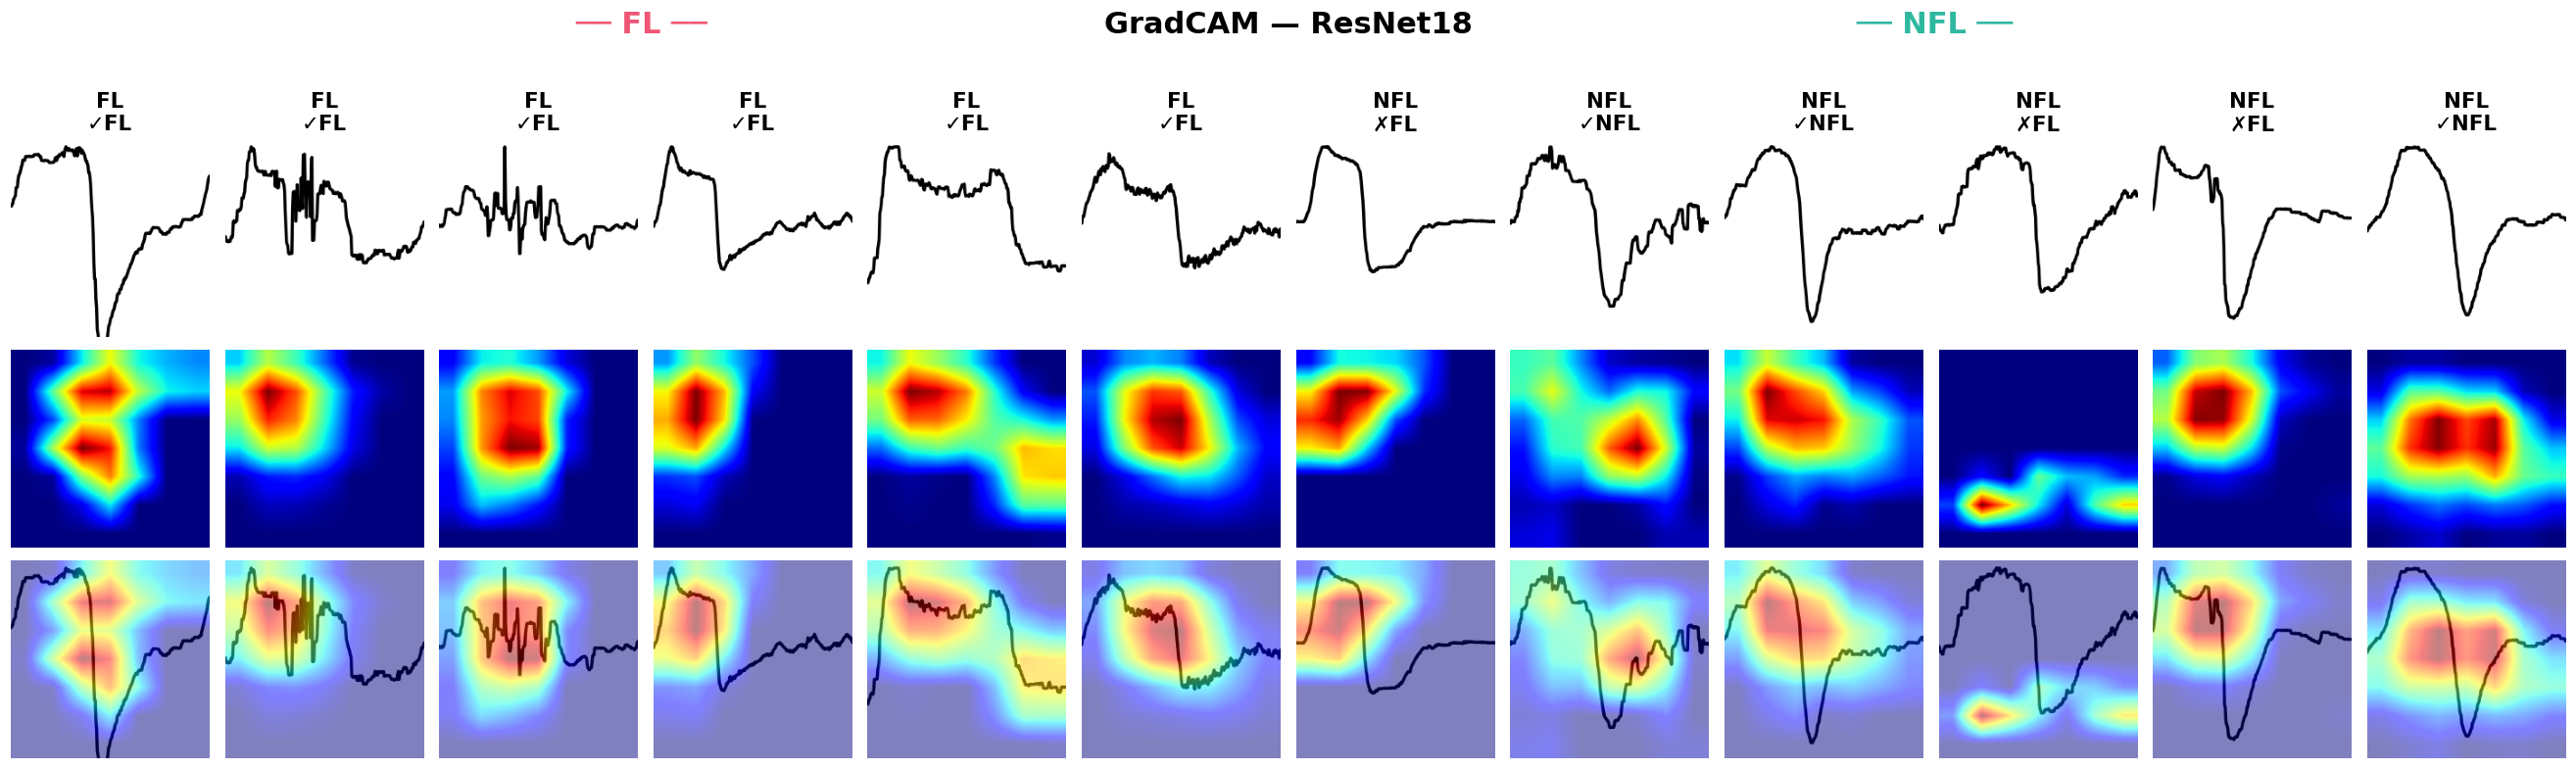

Saved: gradcam_resnet18.png


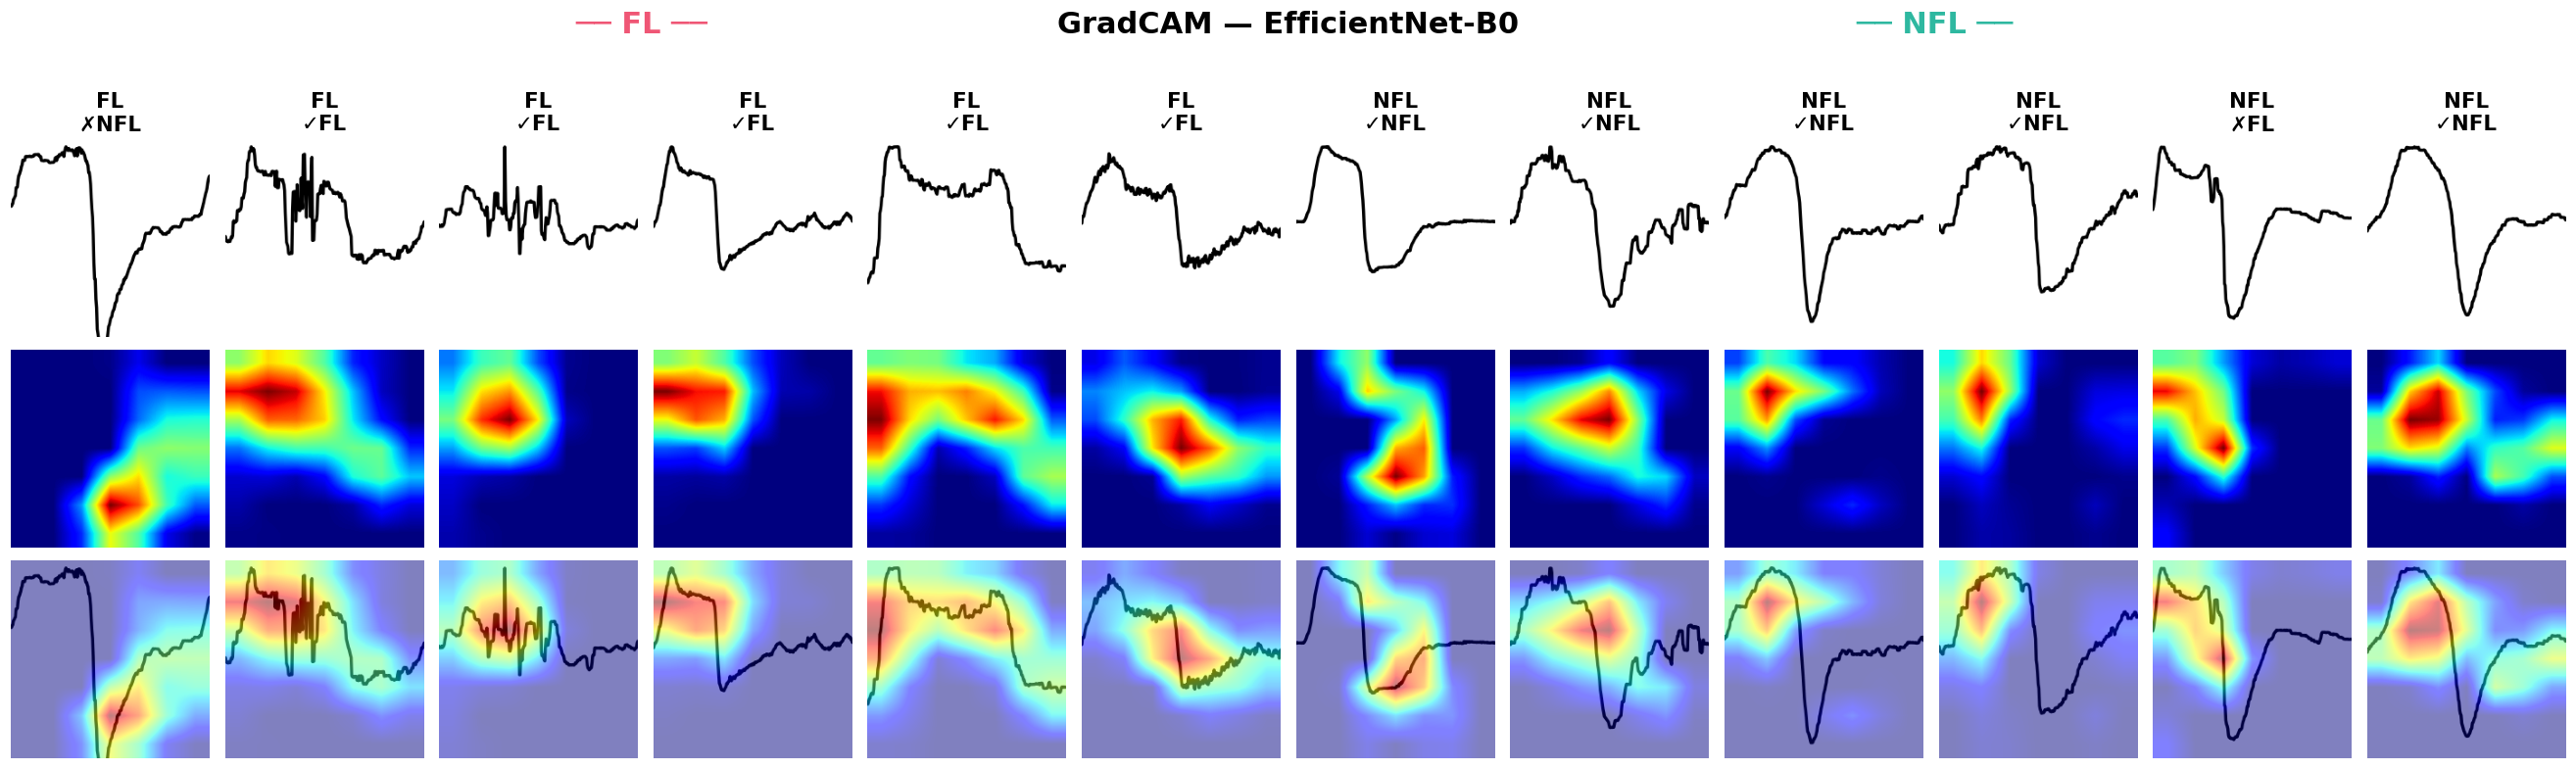

Saved: gradcam_efficientnetb0.png


In [7]:
# ── GradCAM on 6 FL + 6 NFL examples, for all three models ───────────────────
for model_name, model in loaded_models.items():
    gcam = GradCAM(model, GRADCAM_LAYERS[model_name])

    fig, axes = plt.subplots(3, 12, figsize=(24, 7))
    # Row 0: original image  Row 1: GradCAM for predicted class  Row 2: overlay

    for col, (_, row) in enumerate(viz_sample.iterrows()):
        x      = load_tensor(row['path'])
        img_np = tensor_to_display(x)

        with torch.enable_grad():
            logits     = model(x)
            pred_class = logits.argmax(1).item()
            cam        = gcam(x, pred_class)

        true_label = 'FL' if row['target'] == 1 else 'NFL'
        pred_label = 'FL' if pred_class == 1 else 'NFL'
        correct    = '✓' if pred_class == row['target'] else '✗'

        axes[0, col].imshow(img_np, cmap='gray'); axes[0, col].axis('off')
        axes[0, col].set_title(f'{true_label}\n{correct}{pred_label}', fontsize=14, fontweight='bold')

        axes[1, col].imshow(cam, cmap='jet'); axes[1, col].axis('off')

        axes[2, col].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[2, col].imshow(cam, cmap='jet', alpha=0.5); axes[2, col].axis('off')

    for ax, label in zip(axes[:, 0], ['Original', 'GradCAM', 'Overlay']):
        ax.set_ylabel(label, fontsize=16, fontweight='bold')

    fig.text(0.25, 1.0, '── FL ──', ha='center', fontsize=20,
             fontweight='bold', color='#ef5675')
    fig.text(0.75, 1.0, '── NFL ──', ha='center', fontsize=20,
             fontweight='bold', color='#2eb8a0')

    plt.suptitle(f'GradCAM — {model_name}', fontweight='bold', y=1.03, fontsize=20)
    plt.tight_layout()
    fname = f'gradcam_{model_name.lower().replace("-","").replace(" ","_")}.png'
    plt.savefig(OUT_DIR / fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    gcam.remove_hooks()

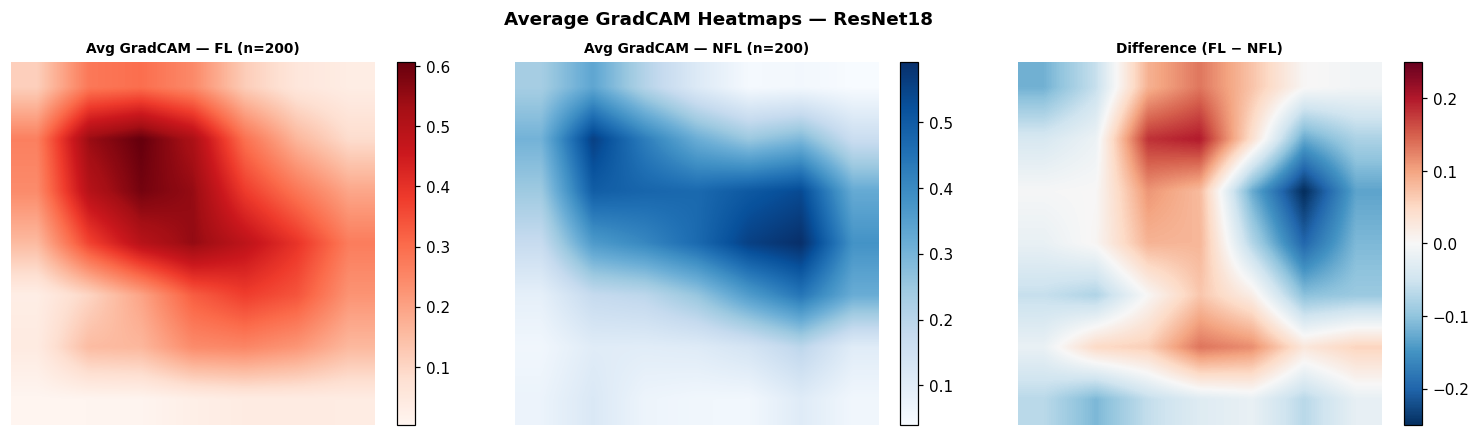

Saved: gradcam_average.png


In [8]:
# ── Average GradCAM: mean heatmap across all FL images vs all NFL images ──────
# Uses the best model. Reveals systematic spatial attention differences.

BEST_MODEL_NAME = 'ResNet18'   # update to whichever was best in notebook 05
best_model = loaded_models[BEST_MODEL_NAME]
gcam_avg   = GradCAM(best_model, GRADCAM_LAYERS[BEST_MODEL_NAME])

avg_cams = {0: [], 1: []}   # target class → list of CAMs
N_AVG = 200                  # use up to 200 images per class for speed

for target in [0, 1]:
    sample = img_df[img_df['target'] == target].sample(
        min(N_AVG, (img_df['target'] == target).sum()), random_state=SEED
    )
    for _, row in sample.iterrows():
        x = load_tensor(row['path'])
        with torch.enable_grad():
            cam = gcam_avg(x, target)
        avg_cams[target].append(cam)

mean_cam_fl  = np.mean(avg_cams[1], axis=0)
mean_cam_nfl = np.mean(avg_cams[0], axis=0)
diff_cam     = mean_cam_fl - mean_cam_nfl   # positive = more attended for FL

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title, cmap in [
    (axes[0], mean_cam_fl,  f'Avg GradCAM — FL (n={len(avg_cams[1])})',  'Reds'),
    (axes[1], mean_cam_nfl, f'Avg GradCAM — NFL (n={len(avg_cams[0])})', 'Blues'),
    (axes[2], diff_cam,     'Difference (FL − NFL)',                      'RdBu_r'),
]:
    if cmap == 'RdBu_r':
        vmax = np.abs(data).max()
        im = ax.imshow(data, cmap=cmap, vmin=-vmax, vmax=vmax)
    else:
        im = ax.imshow(data, cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Average GradCAM Heatmaps — {BEST_MODEL_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gradcam_average.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: gradcam_average.png')
gcam_avg.remove_hooks()